In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r'd:\TIME SERIES\full_data_merged.csv')
df["date"] = pd.to_datetime(df["date"])

# Choose 1 store and 1 family
series = df[(df["store_nbr"] == 1) & (df["family"] == "GROCERY I")]

# Aggregate daily sales
ts = series.groupby("date")["sales"].sum().sort_index()
ts = ts.asfreq('D')

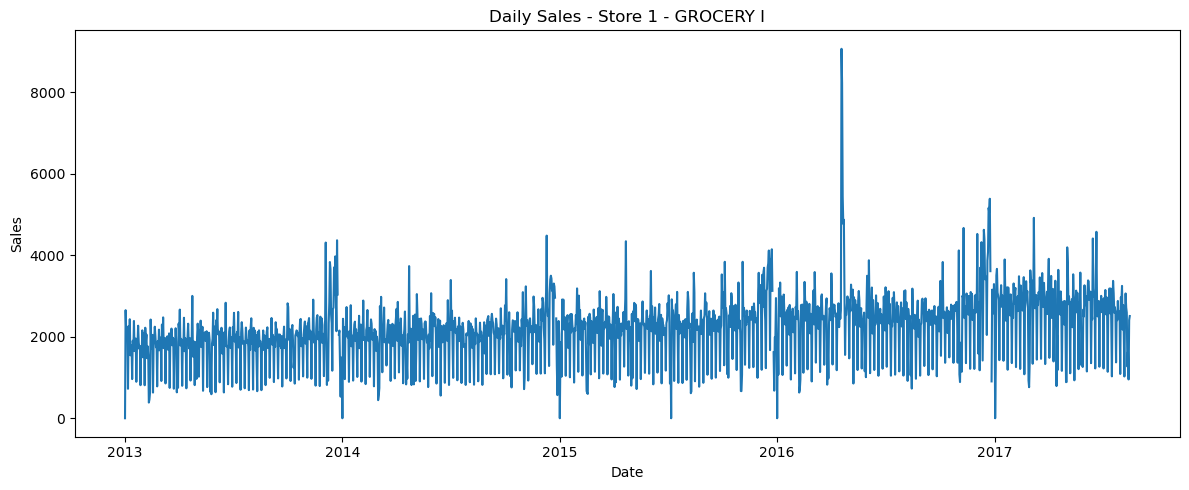

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(ts)
plt.title("Daily Sales - Store 1 - GROCERY I")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

ADF Statistic: -4.150401045659744
p-value: 0.0007985311957746578
Critical Values:
  1%: -3.4343
  5%: -2.8633
  10%: -2.5677


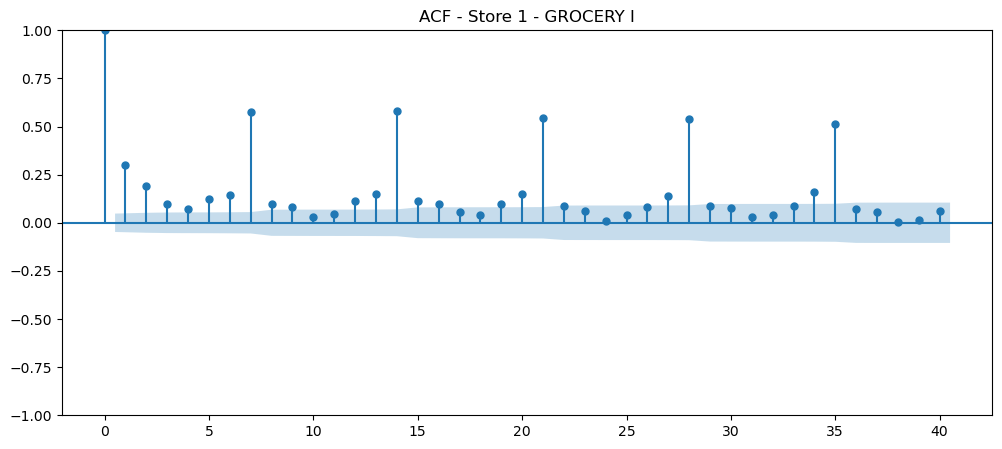

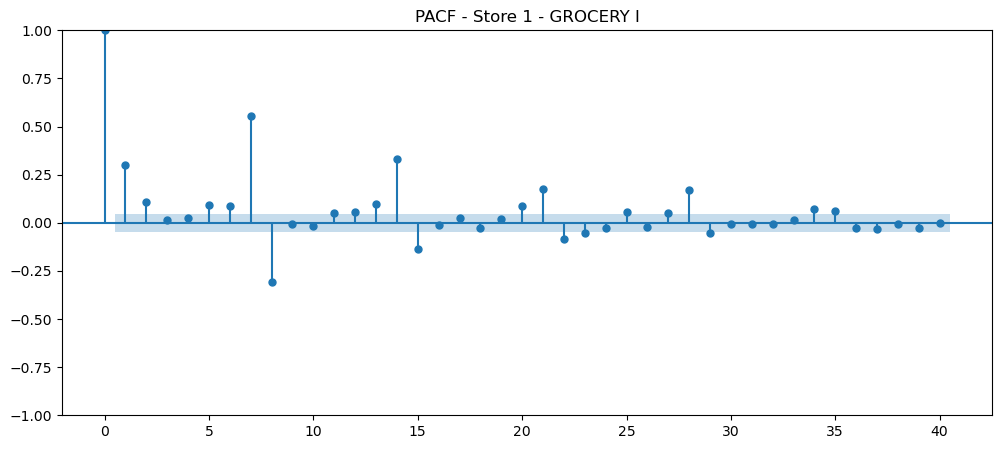

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts.dropna(), lags=40, ax=ax)
plt.title("ACF - Store 1 - GROCERY I")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(ts.dropna(), lags=40, method="ywm", ax=ax)
plt.title("PACF - Store 1 - GROCERY I")
plt.show()

In [5]:
from statsmodels.tsa.arima.model import ARIMA

# AR(1)
model_ar = ARIMA(ts, order=(1, 0, 0)).fit()

# MA(1)
model_ma = ARIMA(ts, order=(0, 0, 1)).fit()

# ARMA(1,1)
model_arma = ARIMA(ts, order=(1, 0, 1)).fit()

print("AR(1)   AIC:", model_ar.aic)
print("MA(1)   AIC:", model_ma.aic)
print("ARMA(1,1) AIC:", model_arma.aic)

AR(1)   AIC: 27047.524968842492
MA(1)   AIC: 27083.698324690675
ARMA(1,1) AIC: 26956.094007545362


In [6]:
print(model_arma.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1688
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -13474.047
Date:                Mon, 27 Apr 2026   AIC                          26956.094
Time:                        12:31:53   BIC                          26977.819
Sample:                    01-01-2013   HQIC                         26964.140
                         - 08-15-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2222.7784    135.345     16.423      0.000    1957.506    2488.050
ar.L1          0.9945      0.003    317.401      0.000       0.988       1.001
ma.L1         -0.9515      0.007   -130.534      0.0

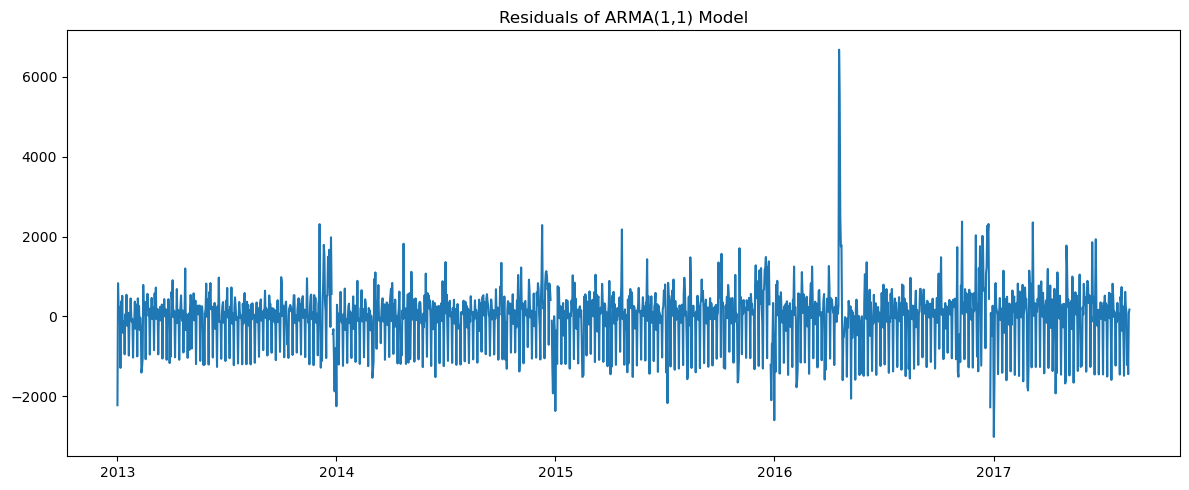

In [7]:
residuals = model_arma.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title("Residuals of ARMA(1,1) Model")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

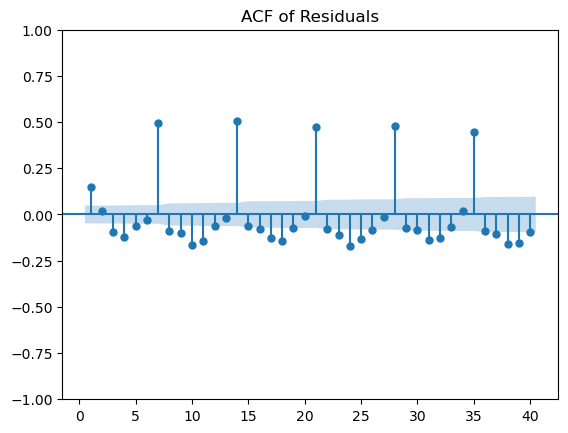

In [8]:
import numpy as np

resid = model_arma.resid.dropna().values

plt.figure(figsize=(12, 5))
plot_acf(resid, lags=40, zero=False)
plt.title("ACF of Residuals")
plt.show()

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(model_arma.resid.dropna(), lags=[10], return_df=True)
print(lb_test)

       lb_stat      lb_pvalue
10  576.335334  2.064388e-117


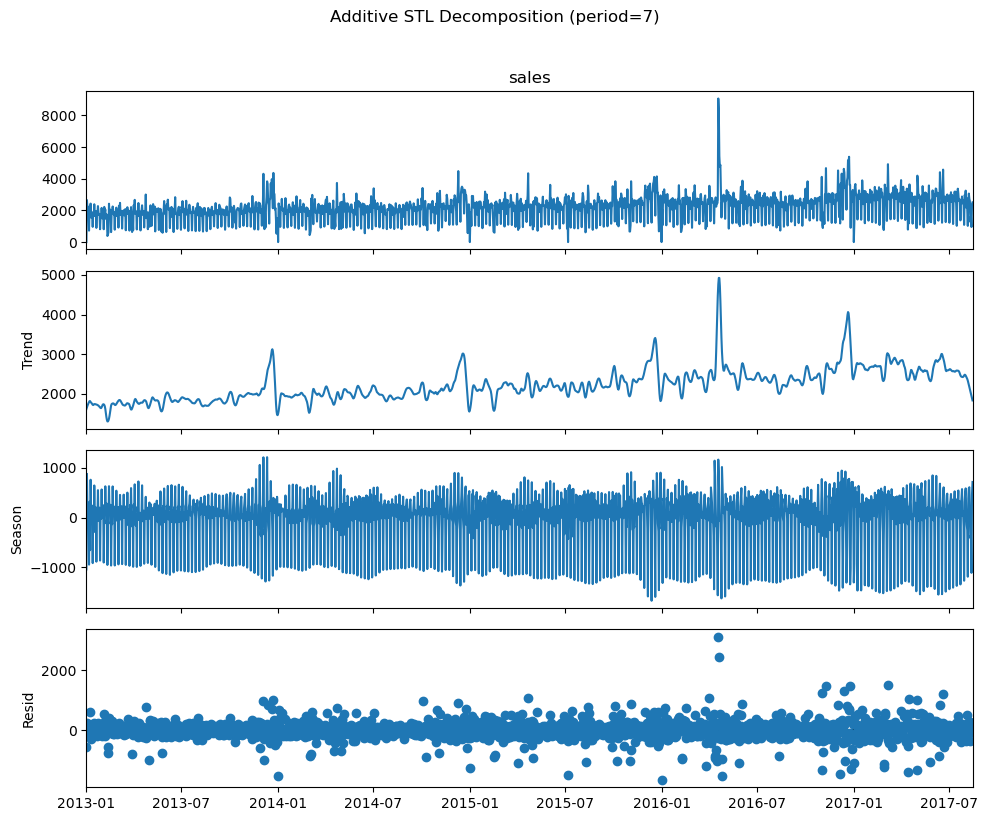

In [10]:
# STL Decomposition 
from statsmodels.tsa.seasonal import STL

ts_stl = ts.ffill().dropna()
stl = STL(ts_stl, period=7)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(10, 8)
plt.suptitle("Additive STL Decomposition (period=7)", y=1.02)
plt.tight_layout()
plt.show()